In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,balanced_accuracy_score,f1_score)

: 

In [4]:
# Load preprocessed datasets
print("Loading Preprocessed Data")
try:
    # load preprocessed datasets
    X_train = pd.read_csv('X_train_scaled.csv')
    X_val = pd.read_csv('X_val_scaled.csv')
    X_test = pd.read_csv('X_test_scaled.csv')

    y_train = pd.read_csv('y_train.csv').squeeze()
    y_val = pd.read_csv('y_val.csv').squeeze()
    y_test = pd.read_csv('y_test.csv').squeeze()

    ### The .squeeze() method removes dimensions of size 1, converting a DataFrame to a Series
    ### The .squeeze() method is a clean, robust way to ensure your target variables are in the correct 1D format that sklearn expects, 
    ### preventing potential errors during model training and evaluation.
    
    # Load preprocessing objects
    scaler =  joblib.load('scaler.pkl')
    selected_features = joblib.load('selected_features.pkl')

    # Display selected features 
    print(f"\nSelected features ({len(selected_features)}):")
    for i, feature in enumerate(selected_features,1):
        print(f"{i:2d}. {feature}")

except FileNotFoundError as e:
    print(f"Error loading preprocessed data: {e}")
    print("Please run the preprocessing notebook first to generate the required files.")
    print("Required files: X_train_scaled.csv, X_val_scaled.csv, X_test_scaled.csv")
    print("                y_train.csv, y_val.csv, y_test.csv")
    print("                scaler.pkl, selected_features.pkl")


Loading Preprocessed Data



Selected features (17):
 1. alcohol
 2. volatile acidity
 3. sulphates
 4. citric acid
 5. density
 6. chlorides
 7. total sulfur dioxide
 8. residual sugar_log
 9. total sulfur dioxide_log
10. chlorides_log
11. FA_to_VA_ratio
12. citric_over_total_acid
13. alcohol_acid_interaction
14. alcohol_density_ratio
15. sulphate_citric_interaction
16. total_acidity
17. ph_acidity_balance


### **2. Baseline Model - Logistic Regression**

In [10]:
# Baseline Logistic Regression model
print("BASELINE LOGISTIC REGRESSION MODEL")
print("EDA recommendation: Fast, interpretable baseline with coefficients for feature effect direction")

# Create and train baseline model
baseline_model = LogisticRegression(random_state=234,max_iter=1000,class_weight='balanced')
baseline_model.fit(X_train,y_train)

# Make predictions 
y_train_pred = baseline_model.predict(X_train)
y_val_pred = baseline_model.predict(X_val)
y_test_pred = baseline_model.predict(X_test)

#Calculate metrics
train_accuracy=  accuracy_score(y_train,y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_balanced_acc = balanced_accuracy_score(y_train, y_train_pred)
val_balanced_acc = balanced_accuracy_score(y_val, y_val_pred)
test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train,y_train_pred,average='macro')
val_f1 = f1_score(y_val,y_val_pred,average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print(f"\nBaseline Model Performance:")
print(f"Training - Accuracy: {train_accuracy:.3f}, Balanced Acc: {train_balanced_acc:.3f}, Macro F1: {train_f1:.3f}")
print(f"Validation - Accuracy: {val_accuracy:.3f}, Balanced Acc: {val_balanced_acc:.3f}, Macro F1: {val_f1:.3f}")
print(f"Test - Accuracy: {test_accuracy:.3f}, Balanced Acc: {test_balanced_acc:.3f}, Macro F1: {test_f1:.3f}")

# Display features coefficients (interpretability)
print(f"\nFeature Coefficients (Top 10):")
feature_imported = pd.DataFrame({'feature': X_train.columns,
    'coefficient': baseline_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)


BASELINE LOGISTIC REGRESSION MODEL
EDA recommendation: Fast, interpretable baseline with coefficients for feature effect direction

Baseline Model Performance:
Training - Accuracy: 0.321, Balanced Acc: 0.504, Macro F1: 0.242
Validation - Accuracy: 0.321, Balanced Acc: 0.443, Macro F1: 0.239
Test - Accuracy: 0.323, Balanced Acc: 0.431, Macro F1: 0.231

Feature Coefficients (Top 10):


### **3. Random forest classifier (EDA RECOMMENDATION)**

RANDOM FOREST CLASSIFIER
EDA recommendation: Robust, captures interactions, insensitive to scaling and moderate outliers

Random Forest Performance:
Training - Accuracy: 1.000, Balanced Acc: 1.000, Macro F1: 1.000
Validation - Accuracy: 0.523, Balanced Acc: 0.221, Macro F1: 0.226
Test - Accuracy: 0.561, Balanced Acc: 0.237, Macro F1: 0.244

Feature Importance (Top 10):
 1. alcohol_density_ratio: 0.095
 2. ph_acidity_balance: 0.086
 3. alcohol: 0.064
 4. total sulfur dioxide_log: 0.064
 5. density: 0.061
 6. total sulfur dioxide: 0.061
 7. chlorides: 0.060
 8. residual sugar_log: 0.059
 9. chlorides_log: 0.059
10. alcohol_acid_interaction: 0.059


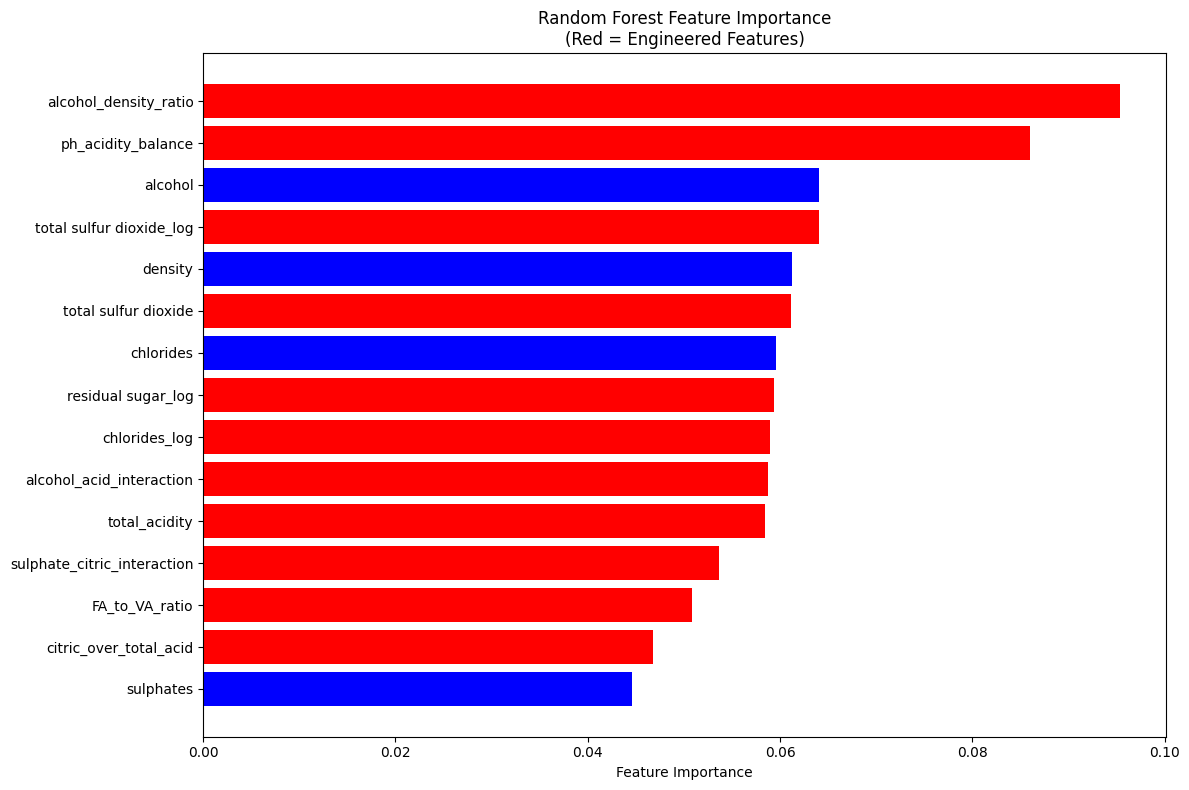

....Random Forest model completed...!


In [12]:
# Random Forest Classifier
print("RANDOM FOREST CLASSIFIER")
print("EDA recommendation: Robust, captures interactions, insensitive to scaling and moderate outliers")

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',  # Handle class imbalance
    n_jobs=-1  # Use all available cores
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)
y_test_pred_rf = rf_model.predict(X_test)

# Calculate metrics
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

train_balanced_acc_rf = balanced_accuracy_score(y_train, y_train_pred_rf)
val_balanced_acc_rf = balanced_accuracy_score(y_val, y_val_pred_rf)
test_balanced_acc_rf = balanced_accuracy_score(y_test, y_test_pred_rf)

train_f1_rf = f1_score(y_train, y_train_pred_rf, average='macro')
val_f1_rf = f1_score(y_val, y_val_pred_rf, average='macro')
test_f1_rf = f1_score(y_test, y_test_pred_rf, average='macro')

print(f"\nRandom Forest Performance:")
print(f"Training - Accuracy: {train_accuracy_rf:.3f}, Balanced Acc: {train_balanced_acc_rf:.3f}, Macro F1: {train_f1_rf:.3f}")
print(f"Validation - Accuracy: {val_accuracy_rf:.3f}, Balanced Acc: {val_balanced_acc_rf:.3f}, Macro F1: {val_f1_rf:.3f}")
print(f"Test - Accuracy: {test_accuracy_rf:.3f}, Balanced Acc: {test_balanced_acc_rf:.3f}, Macro F1: {test_f1_rf:.3f}")

# Feature importance analysis
print(f"\nFeature Importance (Top 10):")
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

for i, (_, row) in enumerate(feature_importance_rf.head(10).iterrows(), 1):
    print(f"{i:2d}. {row['feature']}: {row['importance']:.3f}")

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features_rf = feature_importance_rf.head(15)
colors = ['red' if any(keyword in f.lower() for keyword in ['ratio', 'interaction', 'balance', 'total', 'log']) else 'blue' for f in top_features_rf['feature']]

plt.barh(range(len(top_features_rf)), top_features_rf['importance'], color=colors)
plt.yticks(range(len(top_features_rf)), top_features_rf['feature'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance\n(Red = Engineered Features)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Store Random Forest results
rf_results = {
    'model': 'Random Forest',
    'train_accuracy': train_accuracy_rf,
    'val_accuracy': val_accuracy_rf,
    'test_accuracy': test_accuracy_rf,
    'train_balanced_acc': train_balanced_acc_rf,
    'val_balanced_acc': val_balanced_acc_rf,
    'test_balanced_acc': test_balanced_acc_rf,
    'train_f1': train_f1_rf,
    'val_f1': val_f1_rf,
    'test_f1': test_f1_rf
}

print("....Random Forest model completed...!")


### **4. XGBoost Classifier**

In [15]:
y_train.min()

np.int64(3)